<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h1>راهنمای اجرای سریع</h1>
<p>دفترچه را از بالا به پایین اجرا کنید. سلول <span dir="ltr">Configuration</span> مسیر داده، پارامترهای مدل و بودجهٔ CPU را مشخص می‌کند.</p>
<p>اجرای پیش‌فرض فقط <span dir="ltr">CAB25</span> را اجرا می‌کند؛ اجرای همهٔ داده‌ها با <span dir="ltr">RUN_ALL_DATASETS=True</span> اختیاری است.</p>
</div>

<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>اتصال اختیاری Google Drive</h2>
<p>برای داده‌های موجود در Drive، سلول بعدی را با <span dir="ltr">MOUNT_GOOGLE_DRIVE=True</span> اجرا کنید. برای upload مستقیم، فقط <span dir="ltr">DATA_DIR</span> را تنظیم کنید.</p>
</div>

In [1]:
MOUNT_GOOGLE_DRIVE = False
if MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

In [2]:
from IPython.display import display, HTML
display(HTML('''
<style>
.salh-rtl { direction: rtl; text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9; }
.salh-rtl h1, .salh-rtl h2, .salh-rtl h3, .salh-rtl p, .salh-rtl li { direction: rtl; text-align: right; }
.salh-rtl .salh-ltr, .salh-rtl code { direction: ltr; unicode-bidi: embed; display: inline-block; text-align: left; }
pre, .CodeMirror, .jp-CodeCell, .output pre, table { direction: ltr; text-align: left; }
</style>
'''))

<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>نصب کتابخانه‌ها</h2>
<p>در Colab فقط وابستگی‌های مفقود نصب می‌شوند. اجرای مدل و آموزش سبک فقط به CPU نیاز دارد.</p>
</div>

In [3]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/salh-matplotlib")
import importlib.util
import sys

required = ["numpy", "matplotlib", "openpyxl", "pulp", "torch"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing and "google.colab" in sys.modules:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl", "pulp", "torch"])
elif missing:
    raise RuntimeError(
        "وابستگی‌های زیر نصب نیستند: " + ", ".join(missing)
        + ". فرمان‌های نصب RUN_GUIDE_FA.md را اجرا کنید."
    )

import csv
import itertools
import json
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from openpyxl import load_workbook
import pulp
import torch
from torch import nn

torch.set_num_threads(1)
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | PyTorch {torch.__version__} | CPU")

Python 3.12.3 | NumPy 2.5.2 | PyTorch 2.14.0+cpu | CPU


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۱. بارگذاری دادهٔ شبکه</h2>
<p>ماتریس تقاضای <span dir="ltr">XLSX</span> و ماتریس فاصلهٔ <span dir="ltr">CSV</span> با اعتبارسنجی مربع، متناهی و نامنفی بارگذاری می‌شوند. فقط سرستون شناخته‌شدهٔ فایل <span dir="ltr">XLSX</span> حذف می‌شود.</p>
</div>

In [4]:
DATASETS = {
    "CAB25": ("wij_CAB25.xlsx", "C-CAB25.csv"),
    "AP100": ("wij_AP100.xlsx", "C_AP100.csv"),
    "AP150": ("wij_AP150.xlsx", "C_AP150.csv"),
    "AP200": ("wij_AP200.xlsx", "C_AP200.csv"),
}

def _numeric_square(rows, source):
    try:
        matrix = np.asarray(rows, dtype=float)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"مقدار غیرعددی در {source}") from exc
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError(f"ماتریس {source} باید مربع باشد؛ شکل فعلی {matrix.shape} است.")
    if not np.isfinite(matrix).all() or np.any(matrix < 0):
        raise ValueError(f"ماتریس {source} باید متناهی و نامنفی باشد.")
    return matrix

def load_matrix(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"فایل پیدا نشد: {path}. DATA_DIR را برای Colab upload یا Google Drive تنظیم کنید."
        )
    if path.suffix.lower() == ".csv":
        with path.open(encoding="utf-8-sig", newline="") as stream:
            return _numeric_square(list(csv.reader(stream)), path)
    if path.suffix.lower() == ".xlsx":
        workbook = load_workbook(path, read_only=True, data_only=True)
        rows = list(workbook.active.iter_rows(values_only=True))
        workbook.close()
        if rows and len(rows) == len(rows[0]) + 1:
            header = np.asarray(rows[0], dtype=float)
            if np.array_equal(header, np.arange(header.size)):
                rows = rows[1:]
        return _numeric_square(rows, path)
    raise ValueError(f"پسوند پشتیبانی نمی‌شود: {path.suffix}")

def load_dataset(name, data_dir):
    if name not in DATASETS:
        raise ValueError(f"نام داده باید یکی از {tuple(DATASETS)} باشد.")
    flow_name, distance_name = DATASETS[name]
    demand = load_matrix(Path(data_dir) / flow_name)
    distance = load_matrix(Path(data_dir) / distance_name)
    if demand.shape != distance.shape:
        raise ValueError("ابعاد ماتریس تقاضا و فاصله یکسان نیست.")
    demand = demand.copy()
    np.fill_diagonal(demand, 0.0)
    return distance, demand

<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>پیکربندی</h2>
<p>این سلول را پیش از اجرا بررسی کنید. مقدار پیش‌فرض ۱۰۰ سناریو، <span dir="ltr">p=3</span>، <span dir="ltr">alpha=0.5</span> و <span dir="ltr">beta=0.5</span> است.</p>
</div>

In [5]:
# In the delivery ZIP, data/raw is beside this notebook.  The fallback
# also supports running the tracked notebook from the repository's notebooks/
# directory.  In Colab, set DATA_DIR to the uploaded/Drive data folder.
DATA_DIR = Path("data/raw") if Path("data/raw").is_dir() else Path("../data/raw")
DATASET = "CAB25"
P = 3
ALPHA = 0.5
BETA = 0.5
SCENARIO_COUNT = 100
SCENARIO_SEED = 0
SEARCH_SEED = 0
MAX_ITERATIONS = 2
MAX_EVALUATIONS = 6
TRAIN_RANKER = True
RUN_ALL_DATASETS = False
OUTPUT_DIRECTORY = Path("outputs/notebook_run")

TRAINING_INSTANCES = 4
VALIDATION_FRACTION = 0.25
HIDDEN_DIMENSION = 16
MESSAGE_PASSING_LAYERS = 1
EPOCHS = 4
LEARNING_RATE = 0.01
BATCH_SIZE = 2
PATIENCE = 2
TRAINING_SEED = 0

if SCENARIO_COUNT != 100:
    raise ValueError("مقایسهٔ مصوب باید دقیقاً ۱۰۰ سناریو داشته باشد.")
if not 0 < BETA <= 1:
    raise ValueError("BETA باید در بازهٔ (0, 1] باشد.")

distance, base_demand = load_dataset(DATASET, DATA_DIR)
print(f"{DATASET}: nodes={distance.shape[0]}, demand={base_demand.sum():.2f}")

CAB25: nodes=25, demand=8540006.00


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۲. تولید سناریوهای تقاضا</h2>
<p>برای هر سناریو ضرایب گره مستقل نمونه‌گیری و جریان پواسون نرمال می‌شود. ۱۰۰ سناریو دارای قطر صفر و احتمال صریح یکسان هستند.</p>
</div>

In [6]:
def generate_scenarios(base_flow, count=100, seed=0, retries=3):
    base = np.asarray(base_flow, dtype=float)
    if not isinstance(count, int) or count <= 0:
        raise ValueError("تعداد سناریو باید عدد صحیح مثبت باشد.")
    if base.ndim != 2 or base.shape[0] != base.shape[1] or base.sum() <= 0:
        raise ValueError("تقاضای پایه باید مربع و دارای مجموع مثبت باشد.")
    rng = np.random.default_rng(seed)
    flows = np.empty((count, *base.shape), dtype=float)
    for scenario in range(count):
        for _ in range(retries):
            multipliers = rng.uniform(0.5, 1.5, base.shape[0])
            draw = rng.poisson(multipliers[:, None] * multipliers[None, :] * base).astype(float)
            np.fill_diagonal(draw, 0.0)
            if draw.sum() > 0:
                flows[scenario] = draw / draw.sum()
                break
        else:
            raise RuntimeError(f"سناریوی {scenario} پس از {retries} تلاش جریان مثبت نداشت.")
    probabilities = np.full(count, 1.0 / count)
    assert np.isfinite(flows).all() and np.all(flows >= 0)
    assert np.allclose(np.diagonal(flows, axis1=1, axis2=2), 0)
    assert np.allclose(flows.sum(axis=(1, 2)), 1)
    assert np.isclose(probabilities.sum(), 1)
    return flows, probabilities

scenario_flows, scenario_probabilities = generate_scenarios(
    base_demand, SCENARIO_COUNT, SCENARIO_SEED
)
print("shape:", scenario_flows.shape, "| probability:", scenario_probabilities[0])

shape: (100, 25, 25) | probability: 0.01


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۳. مدل ریاضی تخصیص یگانه</h2>
<p>قرارداد استاندارد این دفترچه <span dir="ltr">z[i,k] = assign[i][k]</span> است. متغیر قطری <span dir="ltr">z[k,k]</span> تصمیم بازبودن هاب است؛ بنابراین <span dir="ltr">sum_k z[k,k]=p</span> دقیقاً p هاب را انتخاب می‌کند.</p>
<p>تخصیص یگانه با <span dir="ltr">sum_k z[i,k]=1</span> و مجازبودن تخصیص فقط به هاب باز با <span dir="ltr">z[i,k] &lt;= z[k,k]</span> اعمال می‌شود. همین دو قید باعث می‌شوند هاب باز به خودش تخصیص داشته باشد و متغیر جداگانهٔ هاب لازم نباشد.</p>
<p>متغیر <span dir="ltr">X[s,i,j,k,m]</span> دودویی است و مسیر یکتای زوج OD را در سناریوی s از هاب‌های تخصیص‌یافته k و m انتخاب می‌کند. قید <span dir="ltr">sum_k,m X[s,i,j,k,m]=1</span> صریحاً نمایش داده می‌شود. شاخص سناریو برای مقایسه با مقاله نگه داشته شده، هرچند تخصیص‌ها مرحلهٔ اول و مشترک‌اند.</p>
<p>فرم مقاله برای سناریوهای هم‌احتمال: <span dir="ltr">K=ceil(beta*S)</span> و میانگین بدترین K هزینه است. وقتی beta*S صحیح باشد، <span dir="ltr">q_s/beta = 1/(beta*S) = 1/K</span> و با فرم وزن‌دار یکسان می‌شود. برای مقدار غیرصحیح، قاعدهٔ ceiling مقاله از فرم وزن‌دار عمومی با اتم مرزی کسری متمایز است.</p>
<p>مقالهٔ جریان ممکن است X را جریان پیوستهٔ نامنفی بداند؛ این تطبیق تخصیص یگانه، X را انتخاب مسیر دودویی می‌گیرد تا رابطهٔ دقیق تخصیص و مسیر روشن باشد.</p>
</div>

In [7]:
@dataclass(frozen=True)
class Candidate:
    hubs: tuple
    assignments: tuple

def validate_candidate(candidate, node_count, p):
    hubs, assignments = tuple(candidate.hubs), tuple(candidate.assignments)
    if len(hubs) != p or len(set(hubs)) != p:
        raise ValueError("candidate must contain exactly p distinct hubs")
    if len(assignments) != node_count or not set(assignments) <= set(hubs):
        raise ValueError("each node must use one open hub")
    if any(assignments[hub] != hub for hub in hubs):
        raise ValueError("every open hub must assign to itself")

def tail_scenario_count(scenario_count, beta):
    if not isinstance(scenario_count, int) or scenario_count <= 0:
        raise ValueError("scenario_count must be a positive integer")
    if not 0 < beta <= 1:
        raise ValueError("beta must satisfy 0 < beta <= 1")
    return int(np.ceil(beta * scenario_count))

def equal_probability_beta_mean(costs, beta):
    values = np.asarray(costs, dtype=float)
    if values.ndim != 1 or values.size == 0 or not np.isfinite(values).all():
        raise ValueError("costs must be a nonempty finite vector")
    K = tail_scenario_count(int(values.size), beta)
    return float(np.mean(np.sort(values)[-K:]))

def conditional_beta_mean(costs, probabilities, beta):
    """Generalized weighted form: eta + sum(q_s max(C_s-eta,0)) / beta."""
    costs, probabilities = np.asarray(costs, float), np.asarray(probabilities, float)
    if costs.ndim != 1 or costs.shape != probabilities.shape:
        raise ValueError("costs and probabilities must have matching shapes")
    if not np.isfinite(costs).all() or not np.isfinite(probabilities).all():
        raise ValueError("costs and probabilities must be finite")
    if np.any(probabilities < 0) or not np.isclose(probabilities.sum(), 1):
        raise ValueError("probabilities must be nonnegative and sum to one")
    if not 0 < beta <= 1:
        raise ValueError("beta must satisfy 0 < beta <= 1")
    eta = np.sort(costs)[min(np.searchsorted(np.cumsum(probabilities[np.argsort(costs)]), 1-beta, side="left"), len(costs)-1)]
    return float(eta + np.dot(probabilities, np.maximum(costs - eta, 0)) / beta)

def scenario_costs(candidate, distance, flows, alpha):
    validate_candidate(candidate, distance.shape[0], len(candidate.hubs))
    assignment = np.asarray(candidate.assignments, int)
    indices = np.arange(distance.shape[0])
    route = (distance[indices, assignment][:, None]
             + alpha * distance[assignment[:, None], assignment[None, :]]
             + distance[assignment[None, :], indices[None, :]])
    return np.einsum("sij,ij->s", flows, route)

def risk_objective(candidate, distance, flows, probabilities, alpha, beta):
    return conditional_beta_mean(scenario_costs(candidate, distance, flows, alpha), probabilities, beta)

equal_costs = np.arange(1.0, 101.0)
equal_probabilities = np.full(100, 0.01)
assert tail_scenario_count(100, 0.5) == 50
assert tail_scenario_count(100, 0.1) == 10
assert equal_probability_beta_mean(equal_costs, 0.5) == conditional_beta_mean(equal_costs, equal_probabilities, 0.5)
assert equal_probability_beta_mean(equal_costs, 0.1) == conditional_beta_mean(equal_costs, equal_probabilities, 0.1)
assert tail_scenario_count(10, 0.25) == 3
assert equal_probability_beta_mean(np.arange(1.0, 11.0), 0.25) == 9.0
assert equal_probability_beta_mean(equal_costs, 0.1) >= equal_probability_beta_mean(equal_costs, 0.5)
print("Risk checks: K(100, 0.5)=50; K(100, 0.1)=10; weighted/integer equality passed.")

Risk checks: K(100, 0.5)=50; K(100, 0.1)=10; weighted/integer equality passed.


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۴. MILP دقیق و اعتبارسنجی brute-force کوچک</h2>
<p>مدل دقیق دودویی <span dir="ltr">X[s,i,j,k,m]</span> فقط برای نمونه‌های بسیار کوچک ساخته می‌شود؛ ساختار آن برای CAB25/AP بزرگ نیست. نگاشت مدل به کد: <span dir="ltr">z[k,k]</span> تصمیم هاب، <span dir="ltr">z[i,k]</span> تخصیص، <span dir="ltr">X</span> انتخاب مسیر، <span dir="ltr">eta</span> آستانهٔ دم و <span dir="ltr">excess[s]</span> همان λ سناریویی است.</p>
<p>قیدهای کد به‌ترتیب: select_p_from_assignment_diagonal، assign_node، assign_only_to_open، one_route، route-origin/destination/product links و tail_excess هستند.</p>
</div>

In [8]:
def solve_exact_binary_route_model(distance, flows, probabilities, p, alpha, beta, time_limit=15):
    """Tiny article-aligned MILP: binary z[i,k] and X[s,i,j,k,m]."""
    n, scenario_count = distance.shape[0], flows.shape[0]
    if n > 6:
        raise ValueError("binary X[s,i,j,k,m] is for tiny verification instances only")
    nodes, scenarios = range(n), range(scenario_count)
    model = pulp.LpProblem("single_allocation_binary_route", pulp.LpMinimize)
    assign = pulp.LpVariable.dicts("assign", (nodes, nodes), cat="Binary")
    route = pulp.LpVariable.dicts("route_select", (scenarios, nodes, nodes, nodes, nodes), cat="Binary")
    eta = pulp.LpVariable("eta", lowBound=0)
    excess = pulp.LpVariable.dicts("excess", scenarios, lowBound=0)

    model += pulp.lpSum(assign[k][k] for k in nodes) == p, "select_p_from_assignment_diagonal"
    for i in nodes:
        model += pulp.lpSum(assign[i][k] for k in nodes) == 1, f"assign_node_{i}"
        for k in nodes:
            model += assign[i][k] <= assign[k][k], f"assign_only_to_open_{i}_{k}"
    scenario_cost = {}
    for s in scenarios:
        for i in nodes:
            for j in nodes:
                model += pulp.lpSum(route[s][i][j][k][m] for k in nodes for m in nodes) == 1, f"one_route_{s}_{i}_{j}"
                for k in nodes:
                    for m in nodes:
                        model += route[s][i][j][k][m] <= assign[i][k]
                        model += route[s][i][j][k][m] <= assign[j][m]
                        model += route[s][i][j][k][m] >= assign[i][k] + assign[j][m] - 1
        scenario_cost[s] = pulp.lpSum(
            float(flows[s,i,j]) * (distance[i,k] + alpha*distance[k,m] + distance[m,j]) * route[s][i][j][k][m]
            for i in nodes for j in nodes for k in nodes for m in nodes
        )
        model += excess[s] >= scenario_cost[s] - eta, f"tail_excess_{s}"
    model += eta + pulp.lpSum(float(probabilities[s] / beta) * excess[s] for s in scenarios)
    status_code = model.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=time_limit))
    hubs = tuple(k for k in nodes if pulp.value(assign[k][k]) > 0.5)
    assignments = tuple(max(nodes, key=lambda k: pulp.value(assign[i][k])) for i in nodes)
    candidate = Candidate(hubs, assignments)
    validate_candidate(candidate, n, p)
    return candidate, float(pulp.value(model.objective)), pulp.LpStatus[status_code]

def brute_force(distance, flows, probabilities, p, alpha, beta):
    best = None
    for hubs in itertools.combinations(range(distance.shape[0]), p):
        for choices in itertools.product(hubs, repeat=distance.shape[0]-p):
            assignments = list(range(distance.shape[0]))
            for node, hub in zip([i for i in range(distance.shape[0]) if i not in hubs], choices):
                assignments[node] = hub
            candidate = Candidate(tuple(hubs), tuple(assignments))
            value = risk_objective(candidate, distance, flows, probabilities, alpha, beta)
            if best is None or value < best[1] - 1e-10:
                best = candidate, value
    return best

tiny_distance = np.array([[0,1,3,4],[1,0,2,3],[3,2,0,1],[4,3,1,0]], float)
tiny_demand = np.array([[0,4,1,0],[2,0,3,1],[1,2,0,4],[0,1,3,0]], float)
tiny_flows, tiny_probabilities = generate_scenarios(tiny_demand, 10, 12)
exact_candidate, exact_value, exact_status = solve_exact_binary_route_model(tiny_distance, tiny_flows, tiny_probabilities, 2, 0.5, 0.5)
brute_candidate, brute_value = brute_force(tiny_distance, tiny_flows, tiny_probabilities, 2, 0.5, 0.5)
assert np.isclose(exact_value, brute_value, atol=1e-7)
print("Exact binary-X MILP:", exact_status, "| hubs:", exact_candidate.hubs, "| objective:", exact_value)
print("Brute force:", brute_candidate.hubs, "| objective:", brute_value)

Exact binary-X MILP: Optimal | hubs: (1, 2) | objective: 1.30402931840003
Brute force: (1, 2) | objective: 1.304029304029304


In [9]:
def nearest_assignments(distance, hubs):
    hubs = tuple(sorted(hubs))
    return tuple(
        node if node in hubs else min(hubs, key=lambda hub: (distance[node, hub], hub))
        for node in range(distance.shape[0])
    )

def initial_candidate(distance, p, rng, scores=None):
    if scores is None:
        hubs = tuple(sorted(map(int, rng.choice(distance.shape[0], p, replace=False))))
    else:
        order = np.lexsort((np.arange(len(scores)), -np.asarray(scores)))
        hubs = tuple(sorted(map(int, order[:p])))
    candidate = Candidate(hubs, nearest_assignments(distance, hubs))
    validate_candidate(candidate, distance.shape[0], p)
    return candidate

def simple_heuristic(distance, flows, probabilities, p, alpha, beta, seed=0, evaluations=8):
    rng = np.random.default_rng(seed)
    incumbent = initial_candidate(distance, p, rng)
    value = risk_objective(incumbent, distance, flows, probabilities, alpha, beta)
    used = 1
    while used < evaluations:
        outgoing = int(rng.choice(incumbent.hubs))
        incoming = int(rng.choice([n for n in range(distance.shape[0]) if n not in incumbent.hubs]))
        hubs = tuple(sorted((set(incumbent.hubs) - {outgoing}) | {incoming}))
        trial = Candidate(hubs, nearest_assignments(distance, hubs))
        trial_value = risk_objective(trial, distance, flows, probabilities, alpha, beta)
        used += 1
        if trial_value < value:
            incumbent, value = trial, trial_value
    return incumbent, value

heuristic_candidate, heuristic_value = simple_heuristic(
    distance, scenario_flows, scenario_probabilities, P, ALPHA, BETA, SEARCH_SEED, 6
)
print("hubs:", heuristic_candidate.hubs, "| objective:", heuristic_value)
print("assignments:", heuristic_candidate.assignments)

hubs: (3, 16, 24) | objective: 1260.932281421219
assignments: (24, 24, 16, 3, 3, 24, 3, 3, 3, 3, 3, 3, 3, 24, 3, 3, 16, 16, 3, 24, 3, 3, 3, 24, 24)


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۵. ساخت چندگراف وزن‌دار و ۶. ساخت ویژگی‌های گره</h2>
<p>سه گراف وزن‌دار تولید می‌شود: تقاضای تولیدکننده، تقاضای جذب‌کننده و گراف فاصله/فضایی. ویژگی‌ها شامل تقاضا، فاصله، مرکز ثقل و ۳۶ جهت هستند. خروجی‌ها باید <span dir="ltr">Node features: (n, 39)</span> و <span dir="ltr">Weighted graphs: (3, n, n)</span> باشند.</p>
</div>

In [10]:
def synthetic_gravity(n=8, seed=0):
    rng = np.random.default_rng(seed)
    coordinates = rng.uniform(0, 100, (n, 2))
    distance = np.linalg.norm(coordinates[:, None] - coordinates[None, :], axis=2)
    populations = np.clip(10 * (rng.pareto(2.0, n) + 1), 10, 100)
    demand = populations[:, None] * populations[None, :] / np.maximum(distance, 1e-6) ** 2
    np.fill_diagonal(demand, 0)
    demand /= demand.max()
    return coordinates, distance, demand

def coverage_graph(demand, incoming=False, threshold=0.8):
    graph = np.zeros_like(demand, float)
    for node in range(demand.shape[0]):
        weights = demand[:, node] if incoming else demand[node]
        total, accumulated = weights.sum(), 0.0
        for other in sorted(range(len(weights)), key=lambda j: (-weights[j], j)):
            if other == node or weights[other] <= 0:
                continue
            graph[node, other] = weights[other]
            accumulated += weights[other]
            if total > 0 and accumulated >= 0.8 * total:
                break
    return graph

def build_graphs(demand, distance, neighbor_fraction=0.2):
    production = coverage_graph(demand, False)
    attraction = coverage_graph(demand, True)
    count = max(1, math.ceil(neighbor_fraction * (distance.shape[0] - 1)))
    selected = np.zeros_like(distance, bool)
    for node in range(distance.shape[0]):
        nearest = sorted(
            (j for j in range(distance.shape[0]) if j != node),
            key=lambda j: (distance[node, j], j),
        )[:count]
        selected[node, nearest] = True
    selected |= selected.T
    spatial = np.zeros_like(distance, float)
    valid = selected & (distance > 1e-12)
    spatial[valid] = 1 / distance[valid]
    spatial = np.maximum(spatial, spatial.T)
    for graph in (production, attraction, spatial):
        np.fill_diagonal(graph, 0)
    return production, attraction, spatial

def classical_mds(distance):
    symmetric = (distance + distance.T) / 2
    np.fill_diagonal(symmetric, 0)
    n = len(distance)
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ symmetric**2 @ centering
    values, vectors = np.linalg.eigh(gram)
    order = np.argsort(values)[::-1][:2]
    coordinates = vectors[:, order] * np.sqrt(np.maximum(values[order], 0))
    for axis in range(2):
        anchor = int(np.argmax(np.abs(coordinates[:, axis])))
        if coordinates[anchor, axis] < 0:
            coordinates[:, axis] *= -1
    return coordinates

def minmax(matrix):
    low, high = matrix.min(axis=0), matrix.max(axis=0)
    span = high - low
    return np.divide(matrix - low, span, out=np.zeros_like(matrix, float), where=span > 1e-12)

def node_features(coordinates, distance, demand, directional_bins=36):
    mass = demand.sum(axis=1) + demand.sum(axis=0)
    center = np.average(coordinates, axis=0, weights=mass if mass.sum() else np.ones(len(mass)))
    center_distance = np.linalg.norm(coordinates - center, axis=1)
    angles = np.mod(np.arctan2(coordinates[:, 1] - center[1], coordinates[:, 0] - center[0]), 2*np.pi)
    bins = np.minimum((angles / (2*np.pi) * directional_bins).astype(int), directional_bins - 1)
    one_hot = np.eye(directional_bins)[bins]
    return minmax(np.column_stack((mass, distance.sum(axis=1), center_distance, one_hot)))

synthetic_coordinates, synthetic_distance, synthetic_demand = synthetic_gravity(seed=TRAINING_SEED)
synthetic_graphs = build_graphs(synthetic_demand, synthetic_distance)
synthetic_features = node_features(synthetic_coordinates, synthetic_distance, synthetic_demand)
assert synthetic_features.shape == (8, 39)
assert np.allclose(synthetic_graphs[2], synthetic_graphs[2].T)
print("features:", synthetic_features.shape, "| graphs:", [g.shape for g in synthetic_graphs])

features: (8, 39) | graphs: [(8, 8), (8, 8), (8, 8)]


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۷. مدل DLHr و ۸. آموزش DLHr</h2>
<p>مدل PyTorch سبک شامل تجمیع سطری سه گراف با self-loop، به‌روزرسانی GRU و اتصال jumping-knowledge است. آموزش CPU فقط با دادهٔ گرانشی مصنوعی انجام می‌شود؛ داده‌های CAB/AP برای آموزش استفاده نمی‌شوند.</p>
</div>

In [11]:
def normalize_graphs(graphs):
    if graphs.ndim == 3:
        graphs = graphs.unsqueeze(0)
    n = graphs.shape[-1]
    values = graphs + torch.eye(n, dtype=graphs.dtype).view(1, 1, n, n)
    return values / values.sum(dim=-1, keepdim=True).clamp_min(1e-12)

class CompactDLHr(nn.Module):
    def __init__(self, input_dimension=39, hidden_dimension=16, layers=1):
        super().__init__()
        self.input_dimension = input_dimension
        self.hidden_dimension = hidden_dimension
        self.layers = layers
        self.input_projection = nn.Linear(input_dimension, hidden_dimension)
        self.message_projection = nn.ModuleList(
            nn.Linear(3 * hidden_dimension, hidden_dimension) for _ in range(layers)
        )
        self.gru = nn.ModuleList(nn.GRUCell(hidden_dimension, hidden_dimension) for _ in range(layers))
        self.decoder = nn.Linear((layers + 1) * hidden_dimension, 1)

    def forward(self, features, graphs):
        unbatched = features.ndim == 2
        if unbatched:
            features, graphs = features[None], graphs[None]
        normalized = normalize_graphs(graphs)
        hidden = torch.tanh(self.input_projection(features))
        representations = [hidden]
        for projection, gru in zip(self.message_projection, self.gru):
            messages = torch.cat([torch.bmm(normalized[:, view], hidden) for view in range(3)], -1)
            update = torch.tanh(projection(messages))
            shape = hidden.shape
            hidden = gru(update.reshape(-1, self.hidden_dimension), hidden.reshape(-1, self.hidden_dimension)).reshape(shape)
            representations.append(hidden)
        scores = self.decoder(torch.cat(representations, -1)).squeeze(-1)
        return scores.squeeze(0) if unbatched else scores

def pairwise_loss(scores, targets):
    target_difference = targets.unsqueeze(-1) - targets.unsqueeze(-2)
    mask = target_difference > 1e-8
    if not mask.any():
        return scores.sum() * 0
    score_difference = scores.unsqueeze(-1) - scores.unsqueeze(-2)
    return torch.nn.functional.softplus(-score_difference[mask]).mean()

def synthetic_training_item(seed):
    coordinates, distance, demand = synthetic_gravity(8, seed)
    flows, probabilities = generate_scenarios(demand, 10, seed)
    counts = np.zeros(8)
    for target_p in (2, 3):
        candidate, _ = simple_heuristic(
            distance, flows, probabilities, target_p, 0.5, 0.5, seed, 8
        )
        counts[list(candidate.hubs)] += 1
    return (
        torch.tensor(node_features(coordinates, distance, demand), dtype=torch.float32),
        torch.tensor(np.stack(build_graphs(demand, distance)), dtype=torch.float32),
        torch.tensor(counts / 2, dtype=torch.float32),
    )

torch.manual_seed(TRAINING_SEED)
np.random.seed(TRAINING_SEED)
random.seed(TRAINING_SEED)
items = [synthetic_training_item(TRAINING_SEED + i) for i in range(TRAINING_INSTANCES)]
split = max(1, int(TRAINING_INSTANCES * (1 - VALIDATION_FRACTION)))
train_items, validation_items = items[:split], items[split:]
ranker = CompactDLHr(39, HIDDEN_DIMENSION, MESSAGE_PASSING_LAYERS)
optimizer = torch.optim.Adam(ranker.parameters(), lr=LEARNING_RATE)
history, best_state, best_validation, stale = [], None, float("inf"), 0

def dataset_loss(dataset):
    return torch.stack([pairwise_loss(ranker(f, g), target) for f, g, target in dataset]).mean()

if TRAIN_RANKER:
    for epoch in range(EPOCHS):
        ranker.train()
        optimizer.zero_grad()
        train_loss = dataset_loss(train_items)
        train_loss.backward()
        optimizer.step()
        ranker.eval()
        with torch.no_grad():
            validation_loss = float(dataset_loss(validation_items or train_items))
        history.append((float(train_loss.detach()), validation_loss))
        if validation_loss < best_validation - 1e-10:
            best_validation = validation_loss
            best_state = {key: value.detach().clone() for key, value in ranker.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                break
    ranker.load_state_dict(best_state)
ranker.eval()
print("epochs:", len(history), "| train/validation loss:", history[-1])

epochs: 4 | train/validation loss: (0.5829953551292419, 0.6119621992111206)


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۹. امتیازهای رتبه‌بندی هاب، ۱۰. GVNS و ۱۱. DL-GVNS</h2>
<p>امتیازهای DLHr با شکل <span dir="ltr">(n,)</span> از ویژگی‌ها و سه گراف ساخته می‌شوند. GVNS مستقل است. DL-GVNS همان سناریوها و همسایگی‌ها را استفاده می‌کند، اما امتیازهای DLHr را برای مقداردهی اولیه و ترتیب نامزدهای جابه‌جایی دریافت می‌کند.</p>
</div>

In [12]:
def swap_neighbors(candidate, distance, scores=None):
    hubs = list(candidate.hubs)
    closed = [node for node in range(distance.shape[0]) if node not in hubs]
    if scores is not None:
        hubs.sort(key=lambda hub: (scores[hub], hub))
        closed.sort(key=lambda node: (-scores[node], node))
    for outgoing in hubs:
        for incoming in closed:
            new_hubs = tuple(sorted((set(candidate.hubs) - {outgoing}) | {incoming}))
            yield Candidate(new_hubs, nearest_assignments(distance, new_hubs))

def reassignment_neighbors(candidate):
    for node, current_hub in enumerate(candidate.assignments):
        if node in candidate.hubs:
            continue
        for replacement_hub in candidate.hubs:
            if replacement_hub == current_hub:
                continue
            assignments = list(candidate.assignments)
            assignments[node] = replacement_hub
            yield Candidate(candidate.hubs, tuple(assignments))

def shake(candidate, distance, rng, depth, scores=None):
    hubs = set(candidate.hubs)
    removable, available = set(hubs), set(range(distance.shape[0])) - hubs
    for _ in range(min(depth, len(removable), len(available))):
        if scores is None:
            outgoing = int(rng.choice(sorted(removable)))
            incoming = int(rng.choice(sorted(available)))
        else:
            outgoing = min(removable, key=lambda hub: (scores[hub], hub))
            incoming = min(available, key=lambda node: (-scores[node], node))
        hubs.remove(outgoing)
        hubs.add(incoming)
        removable.remove(outgoing)
        available.remove(incoming)
    hubs = tuple(sorted(hubs))
    return Candidate(hubs, nearest_assignments(distance, hubs))

def gvns(method, distance, flows, probabilities, scores=None):
    started = time.perf_counter()
    rng = np.random.default_rng(SEARCH_SEED)
    incumbent = initial_candidate(distance, P, rng, scores)
    value = risk_objective(incumbent, distance, flows, probabilities, ALPHA, BETA)
    evaluations, iterations = 1, 0
    while iterations < MAX_ITERATIONS and evaluations < MAX_EVALUATIONS:
        depth = 1 if iterations % 2 == 0 else min(2, P, distance.shape[0] - P)
        trial = shake(incumbent, distance, rng, depth, scores)
        trial_value = risk_objective(trial, distance, flows, probabilities, ALPHA, BETA)
        evaluations += 1
        for neighbor in swap_neighbors(trial, distance, scores):
            if evaluations >= MAX_EVALUATIONS:
                break
            neighbor_value = risk_objective(neighbor, distance, flows, probabilities, ALPHA, BETA)
            evaluations += 1
            if neighbor_value < trial_value - 1e-12:
                trial, trial_value = neighbor, neighbor_value
        for neighbor in reassignment_neighbors(trial):
            if evaluations >= MAX_EVALUATIONS:
                break
            neighbor_value = risk_objective(neighbor, distance, flows, probabilities, ALPHA, BETA)
            evaluations += 1
            if neighbor_value < trial_value - 1e-12:
                trial, trial_value = neighbor, neighbor_value
        if trial_value < value - 1e-12:
            incumbent, value = trial, trial_value
        iterations += 1
    validate_candidate(incumbent, distance.shape[0], P)
    return {
        "method": method,
        "objective": float(value),
        "runtime": time.perf_counter() - started,
        "evaluation_count": evaluations,
        "iteration_count": iterations,
        "hubs": list(incumbent.hubs),
        "assignments": list(incumbent.assignments),
        "status": "evaluation budget reached" if evaluations >= MAX_EVALUATIONS else "iteration limit reached",
        "proven_optimal": False,
    }

def rank_scores(distance, demand):
    geometric_distance = np.asarray(distance, float).copy()
    np.fill_diagonal(geometric_distance, 0)
    coordinates = classical_mds(geometric_distance)
    features = torch.tensor(node_features(coordinates, geometric_distance, demand), dtype=torch.float32)
    graphs = torch.tensor(np.stack(build_graphs(demand, geometric_distance)), dtype=torch.float32)
    with torch.no_grad():
        scores = ranker(features, graphs).numpy().astype(float)
    if not np.isfinite(scores).all():
        raise RuntimeError("رتبه‌بند امتیاز نامتناهی تولید کرد.")
    return scores

def paired_run(dataset_name):
    current_distance, current_demand = load_dataset(dataset_name, DATA_DIR)
    flows, probabilities = generate_scenarios(current_demand, SCENARIO_COUNT, SCENARIO_SEED)
    scores = rank_scores(current_distance, current_demand)
    print(f"DLHr scores: {scores.shape}")
    baseline = gvns("gvns", current_distance, flows, probabilities)
    guided = gvns("dl_gvns", current_distance, flows, probabilities, scores)
    for result in (baseline, guided):
        result.update({
            "dataset": dataset_name, "scenario_count": SCENARIO_COUNT,
            "scenario_seed": SCENARIO_SEED, "search_seed": SEARCH_SEED,
            "p": P, "alpha": ALPHA, "beta": BETA,
        })
        validate_candidate(
            Candidate(tuple(result["hubs"]), tuple(result["assignments"])),
            current_distance.shape[0], P,
        )
    return baseline, guided

print("Pipeline trace: Network data -> Multi-graph construction -> Node features -> DLHr -> Hub-ranking scores -> DL-GVNS -> Final solution")
results = list(paired_run("CAB25"))
if RUN_ALL_DATASETS:
    for optional_dataset in ("AP100", "AP150", "AP200"):
        results.extend(paired_run(optional_dataset))

for result in results:
    print("\nMethod:", result["method"], "| Hubs:", result["hubs"])
    print("Objective:", result["objective"], "| Runtime:", result["runtime"], "| Status:", result["status"])
    print("Assignments:", result["assignments"])

Pipeline trace: Network data -> Multi-graph construction -> Node features -> DLHr -> Hub-ranking scores -> DL-GVNS -> Final solution
DLHr scores: (25,)

Method: gvns | Hubs: [3, 15, 19]
Objective: 1332.105629863629 | Runtime: 0.0007755649999126035 | Status: evaluation budget reached
Assignments: [15, 19, 19, 3, 3, 19, 15, 3, 19, 15, 3, 15, 15, 15, 3, 15, 19, 19, 15, 19, 3, 3, 3, 15, 19]

Method: dl_gvns | Hubs: [0, 3, 16]
Objective: 1222.4171239357704 | Runtime: 0.000553330000002461 | Status: evaluation budget reached
Assignments: [0, 16, 16, 3, 3, 3, 0, 3, 3, 0, 3, 3, 0, 0, 3, 0, 16, 16, 3, 16, 3, 3, 3, 0, 16]


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۱۲. مقایسهٔ زوجی و جواب نهایی</h2>
<p>در هر زوج، سناریوها، احتمال‌ها، بذرها، p، alpha، beta و بودجهٔ ارزیابی یکسان‌اند. جدول و نمودارهای زیر هدف، زمان، هاب‌ها و تخصیص کامل را نشان می‌دهند. تمام جواب‌های GVNS و DL-GVNS ابتکاری و فاقد اثبات بهینگی‌اند.</p>
</div>

dataset | method | objective | runtime | evaluations | hubs | proven_optimal
--------------------------------------------------------------------------------------------------------------
CAB25 | gvns | 1332.1056298636 | 0.000776 | 6 | [3, 15, 19] | False
CAB25 | dl_gvns | 1222.4171239358 | 0.000553 | 6 | [0, 3, 16] | False


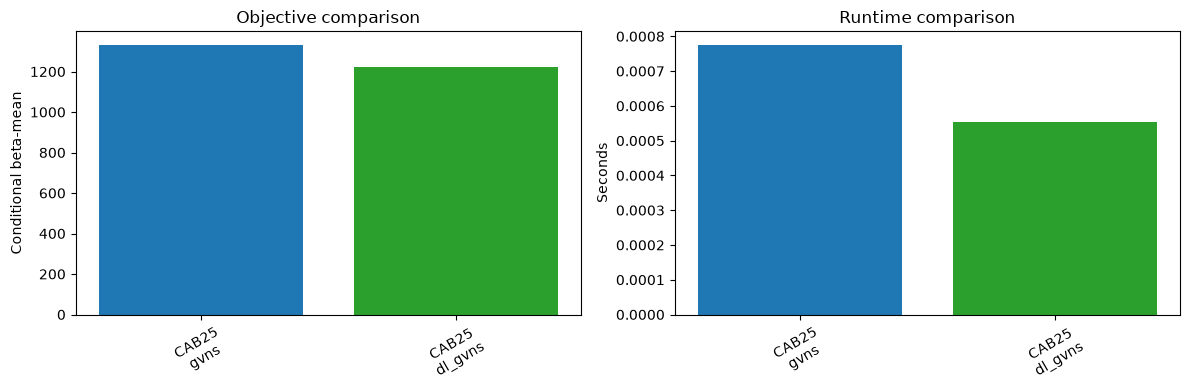

In [13]:
print("dataset | method | objective | runtime | evaluations | hubs | proven_optimal")
print("-" * 110)
for result in results:
    print(
        f"{result['dataset']} | {result['method']} | {result['objective']:.10f} | "
        f"{result['runtime']:.6f} | {result['evaluation_count']} | "
        f"{result['hubs']} | {result['proven_optimal']}"
    )

labels = [f"{result['dataset']}\n{result['method']}" for result in results]
colors = ["tab:blue" if result["method"] == "gvns" else "tab:green" for result in results]
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, [result["objective"] for result in results], color=colors)
axes[0].set_title("Objective comparison")
axes[0].set_ylabel("Conditional beta-mean")
axes[1].bar(labels, [result["runtime"] for result in results], color=colors)
axes[1].set_title("Runtime comparison")
axes[1].set_ylabel("Seconds")
for axis in axes:
    axis.tick_params(axis="x", rotation=30)
figure.tight_layout()
plt.show()

In [14]:
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
json_path = OUTPUT_DIRECTORY / "notebook_results.json"
csv_path = OUTPUT_DIRECTORY / "notebook_summary.csv"
objective_path = OUTPUT_DIRECTORY / "notebook_objective.png"
runtime_path = OUTPUT_DIRECTORY / "notebook_runtime.png"
checkpoint_path = OUTPUT_DIRECTORY / "notebook_ranker.pt"

json_path.write_text(json.dumps(results, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
fields = [
    "dataset", "method", "objective", "runtime", "evaluation_count",
    "iteration_count", "hubs", "status", "proven_optimal",
]
with csv_path.open("w", encoding="utf-8", newline="") as stream:
    writer = csv.DictWriter(stream, fieldnames=fields)
    writer.writeheader()
    for result in results:
        writer.writerow({field: result[field] for field in fields})

def save_bar(field, title, ylabel, path):
    fig, axis = plt.subplots(figsize=(7, 4))
    axis.bar(labels, [result[field] for result in results], color=colors)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    plt.close(fig)

save_bar("objective", "Objective comparison", "Conditional beta-mean", objective_path)
save_bar("runtime", "Runtime comparison", "Seconds", runtime_path)
torch.save({
    "model": {
        "input_dimension": 39,
        "hidden_dimension": HIDDEN_DIMENSION,
        "layers": MESSAGE_PASSING_LAYERS,
    },
    "state_dict": {key: value.detach().cpu() for key, value in ranker.state_dict().items()},
    "training": {"instances": TRAINING_INSTANCES, "epochs": len(history), "seed": TRAINING_SEED},
}, checkpoint_path)

for output in (json_path, csv_path, objective_path, runtime_path, checkpoint_path):
    assert output.is_file() and output.stat().st_size > 0
    print(output, "|", output.stat().st_size, "bytes")

assert all(not result["proven_optimal"] for result in results)
assert all(np.isfinite(result["objective"]) and np.isfinite(result["runtime"]) for result in results)
print("Notebook execution completed successfully.")

outputs/notebook_run/notebook_results.json | 1376 bytes
outputs/notebook_run/notebook_summary.csv | 300 bytes
outputs/notebook_run/notebook_objective.png | 23990 bytes
outputs/notebook_run/notebook_runtime.png | 23449 bytes
outputs/notebook_run/notebook_ranker.pt | 16645 bytes
Notebook execution completed successfully.


<div dir="rtl" class="salh-rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
<h2>۱۳. محدودیت‌ها و تفسیر</h2>
<p>این یک پیاده‌سازی سبک و CPU-ready پایان‌نامه‌ای است، نه بازتولید کامل مقاله‌ها یا آزمایش در مقیاس کامل آن‌ها. DL-GVNS تضمین نمی‌کند همیشه بهتر از GVNS باشد. CBS، DL-CBS، Benders و آموزش در مقیاس مقاله خارج از دامنه هستند.</p>
</div>